# 01 - Exploratory Data Analysis 
**Goal:** Understand the structure, quality and patterns in the Telco churn dataset.

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style='whitegrid')

print("Libraries Loaded")

Libraries Loaded


### Load the Dataset

In [2]:
df = pd.read_csv('../data/telco_churn.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### Checking for Missing values

In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)

Columns with missing values:
Series([], dtype: int64)


In [5]:
print(df['TotalCharges'].dtype)

problem_rows = df[df['TotalCharges'].str.strip() == '']
print(f"Rows with blank TotalCharges: {len(problem_rows)}")

str
Rows with blank TotalCharges: 11


'TotalCharges' appears complete but contains 11 blank string values that isnull() does not detect. Requires manual conversion and cleaning. 

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn rate: (np.float64(26.536987079369588), 1)%
No Churn rate: (np.float64(73.4630129206304), 1)%


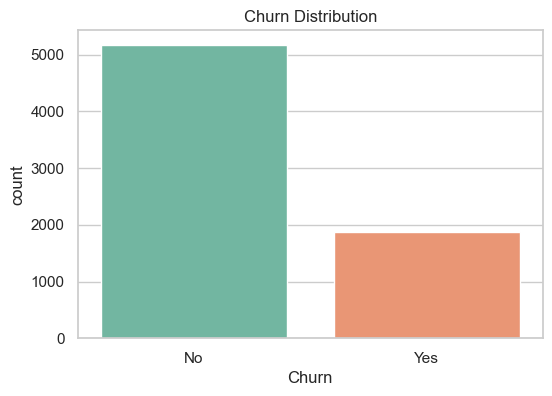

In [6]:
churn_counts = df['Churn'].value_counts()
total = len(df)
print(churn_counts)
print(f"Churn rate: {churn_counts['Yes'] / len(df) * 100, 1}%")
print(f"No Churn rate: {churn_counts['No'] / len(df) * 100, 1}%")

#plotting churn distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='Set2', hue='Churn', legend=False)
plt.title('Churn Distribution')
plt.savefig('../data/churn_distribution.png', bbox_inches='tight')
plt.show()

#### Observation - Target Variable Distribution

The dataset shows a **26.5% churn rate**, indicating moderate class imbalance.
This will require handling during modeling (e.g. class_weight or SMOTE)
to prevent the model from being biased toward the majority class.

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Churn vs Tenure

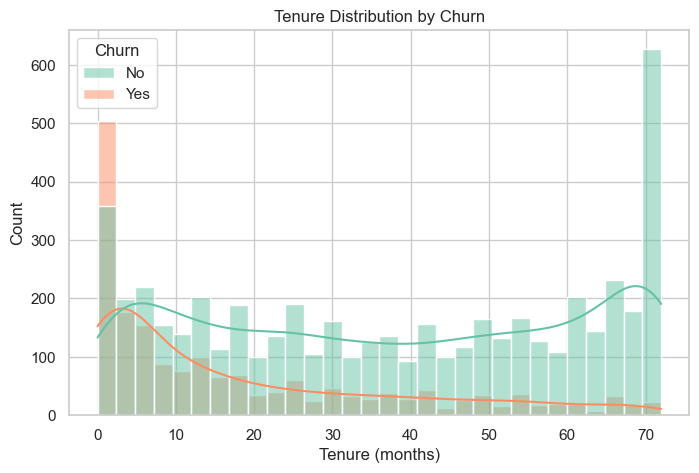

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True, palette='Set2')
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.savefig('../data/tenure_distribution.png', bbox_inches='tight')
plt.show()

### Churn vs Monthly Charges

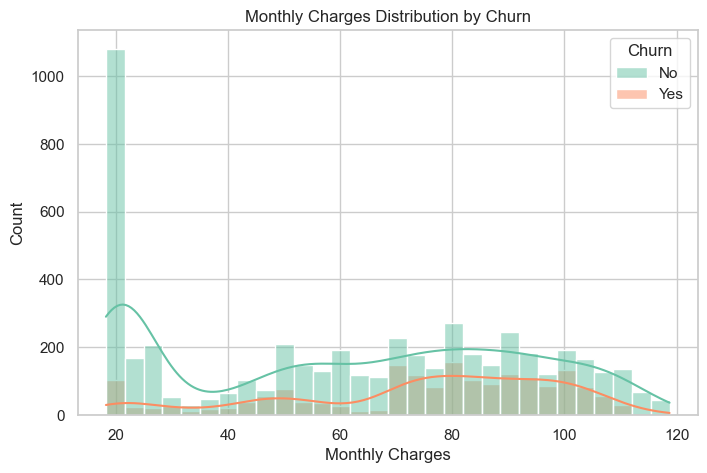

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, kde=True, palette='Set2')
plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Monthly Charges')
plt.savefig('../data/monthly_charges_distribution.png', bbox_inches='tight')
plt.show()

### Churn vs Contact Type

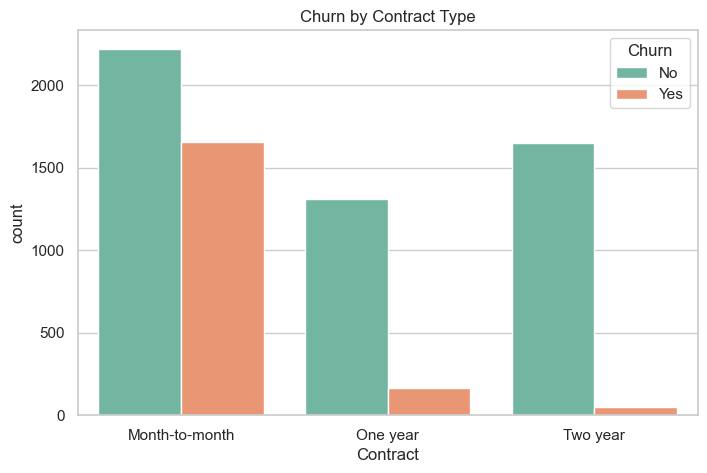

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', data=df, hue='Churn', palette='Set2')
plt.title('Churn by Contract Type')
plt.savefig('../data/churn_by_contract.png', bbox_inches='tight')
plt.show()

### Churn vs Internet Service

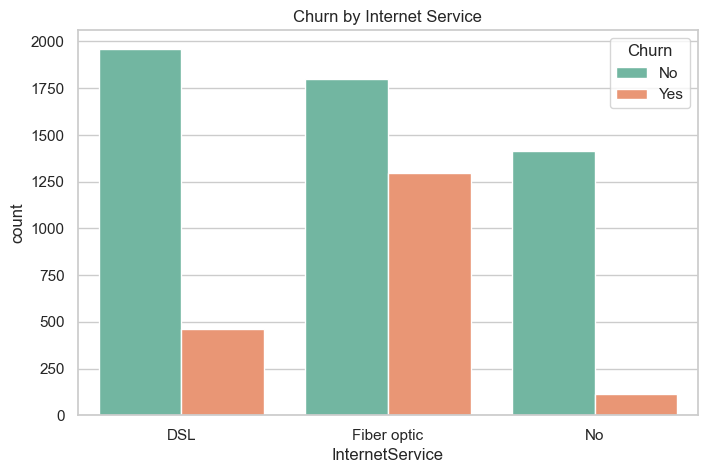

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x='InternetService', data=df, hue='Churn', palette='Set2')
plt.title('Churn by Internet Service')
plt.savefig('../data/churn_by_internet_service.png', bbox_inches='tight')
plt.show()

### Correlation Heatmap (Numerical Only)

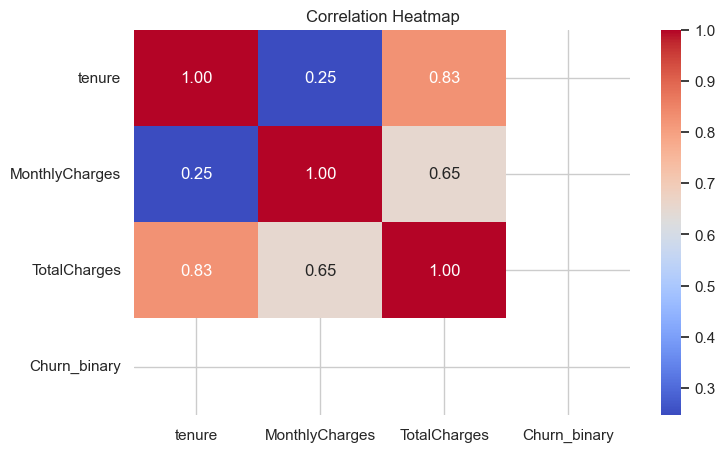

In [12]:
df_temp = df.copy()
df_temp['TotalCharges'] = pd.to_numeric(df_temp['TotalCharges'], errors='coerce')
df_temp['Churn_binary'] = df_temp['Churn'].map({'yes': 1, 'no': 0})

plt.figure(figsize=(8,5))
sns.heatmap(
    df_temp[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_binary']].corr(),
    annot=True, cmap='coolwarm', fmt='.2f'
)
plt.title('Correlation Heatmap')
plt.savefig('../data/correlation_heatmap.png', bbox_inches='tight')
plt.show()

## Key Findings from EDA

1. **Churn rate is ~26%** - dataset is imbalanced, will need to handle in modeling
2. **Tenure** - churned customers have significantly lower tenure (leave early)
3. **Monthly Charges** - higher charges correlate with higher churn
4. **Contract Type** - month-to-month customers churn far more than 1 or 2 year contracts
5. **Internet Service** - Fiber optic customers show higher churn despite premium pricing

## Issues to Fix in Preprocessing
- `TotalCharges` is object type - convert to numeric
- 11 rows with blank TotalCharges - decide to drop or impute
- `Churn` column needs to be encoded as 0/1 for modeling

In [13]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

df.to_csv('../data/telco_after_eda.csv', index=False)
print(f"Saved cleaned data: {df.shape} rows")

Saved cleaned data: (7032, 21) rows
